## How to read Tree files (`.valtree.root` files)

In [1]:
import ROOT
file = "/eos/user/o/oarquero/TB2026CERN/data/TB2026CERN_run_000007/ecal_TB2026CERN_run_000007.valtree.root"
f = ROOT.TFile.Open(file)

In [2]:
f.ls()
t = f.Get("ecal")
# All the information about the branches can be found in the README.md
t.Print()

TNetXNGFile**		root://eoshome-o.cern.ch//eos/user/o/oarquero/TB2026CERN/data/TB2026CERN_run_000007/ecal_TB2026CERN_run_000007.valtree.root	
 TNetXNGFile*		root://eoshome-o.cern.ch//eos/user/o/oarquero/TB2026CERN/data/TB2026CERN_run_000007/ecal_TB2026CERN_run_000007.valtree.root	
  KEY: TTree	ecal;2	ecal [current cycle]
  KEY: TTree	ecal;1	ecal [backup cycle]
******************************************************************************
*Tree    :ecal      : ecal                                                   *
*Entries :     6342 : Total =       117598225 bytes  File  Size =   54464598 *
*        :          : Tree compression factor =   2.16                       *
******************************************************************************
*Br    0 :run       : run/I                                                  *
*Entries :     6342 : Total  Size=      25985 bytes  File Size  =        440 *
*Baskets :        2 : Basket Size=      24242 bytes  Compression=  57.97     *
*......

In [7]:
# With RDataFrame is easier to explore
df = ROOT.RDataFrame("ecal", file)
print(df.GetColumnNames())
h = df.Histo1D("nhit")
c = ROOT.TCanvas()
h.Draw()
c.Draw()

{ "bar_r", "bar_x", "bar_y", "bcid", "e_over_nhit", "energy", "energy_per_layer", "event", "first_layer", "hit_chan", "hit_chip", "hit_energy", "hit_hg", "hit_lg", "hit_sca", "hit_slab", "hit_x", "hit_y", "hit_z", "hits_per_layer", "is_shower", "last_layer", "mip_likeness", "moliere", "n_layers_hit", "nhit", "nhit_chan", "nhit_chip", "nhit_slab", "run", "shower_end", "shower_end_10", "shower_length", "shower_max", "shower_start", "shower_start_10", "spill", "sum_energy", "sum_hg", "transverse_rms", "weighte", "weighte_per_layer", "zbary" }


In [28]:
# With RDataFrame is easier to explore
df = ROOT.RDataFrame("ecal", file)
print(df.GetColumnNames())
h = df.Histo1D("energy")
c = ROOT.TCanvas()
h.Draw()
c.Draw()

{ "bar_r", "bar_x", "bar_y", "bcid", "e_over_nhit", "energy", "energy_per_layer", "event", "first_layer", "hit_chan", "hit_chip", "hit_energy", "hit_hg", "hit_lg", "hit_sca", "hit_slab", "hit_x", "hit_y", "hit_z", "hits_per_layer", "is_shower", "last_layer", "mip_likeness", "moliere", "n_layers_hit", "nhit", "nhit_chan", "nhit_chip", "nhit_slab", "run", "shower_end", "shower_end_10", "shower_length", "shower_max", "shower_start", "shower_start_10", "spill", "sum_energy", "sum_hg", "transverse_rms", "weighte", "weighte_per_layer", "zbary" }


In [ ]:
# Get event index (is an special code, not 0,1,...)
# Select an event wich is probably an electron
events = df.Filter("mip_likeness < 0.05").AsNumpy(["event"])
# Other variables could be used for filtering, i.e. nhit

In [8]:
event = events["event"][0]
data_0 = df.Filter(f"event == {event}").AsNumpy()

# Get coordinates
hit_x = data_0["hit_x"][0]
hit_y = data_0["hit_y"][0]
hit_z = data_0["hit_z"][0]

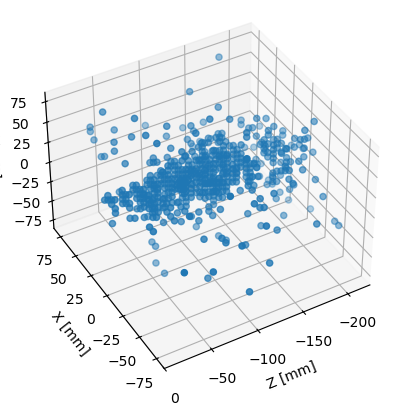

In [27]:
# Plot projections
import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

ax.scatter(hit_z, hit_x, hit_y)
ax.set(
    xlabel='Z [mm]',
    ylabel='X [mm]',
    zlabel='Y [mm]',

    xlim=(0,-225),
    ylim=(-86.30,86.30),
    zlim=(-86.30,86.30)
    
)
ax.view_init(40, -120, 0)
plt.show()

## How to read Tree files (`.edm4hep.root` files)

This format is easier to use with edm4hep pipelines, with more difficult to explore data, as high level features are stored in a more "complicated" way (see README.md).

In [ ]:
# For edm4hep, we use Podio
from podio.root_io import Reader
edm4hep_events = "/eos/user/o/oarquero/TB2026CERN/data/TB2026CERN_run_000048/ecal_TB2026CERN_run_000048.edm4hep.root"
reader = Reader(edm4hep_events)
print(reader.categories)

('metadata', 'events', 'configuration_metadata')


In [37]:
for event in reader.get("events"):
  hits = event.get("ECalHits")
  print("Number of hits:", len(hits))
  for hit in hits:
    p = hit.getPosition()
    print(f"x :{round(p.x, 2)}, y {round(p.y, 2)}, z {round(p.z, 2)}, Energy {round(hit.getEnergy(), 3)}")
  break

Number of hits: 494
x :3.8, y 14.8, z -11.0, Energy 11.1
x :14.8, y 9.3, z -11.0, Energy 2.5
x :3.8, y 20.3, z -11.0, Energy 5.8
x :-3.8, y 20.3, z -11.0, Energy 32.3
x :-9.3, y 20.3, z -11.0, Energy 4.15
x :-3.8, y 14.8, z -11.0, Energy 9.85
x :42.3, y -9.3, z -11.0, Energy 2.35
x :31.3, y -9.3, z -11.0, Energy 2.95
x :31.3, y -3.8, z -11.0, Energy 1.6
x :47.8, y 25.8, z -22.0, Energy 2.6
x :14.8, y 31.3, z -22.0, Energy 1.6
x :-14.8, y 3.8, z -22.0, Energy 1.4
x :-20.3, y 31.3, z -22.0, Energy 12.0
x :-14.8, y 25.8, z -22.0, Energy 1.4
x :-9.3, y 9.3, z -22.0, Energy 3.6
x :-3.8, y 3.8, z -22.0, Energy 5.45
x :-14.8, y 20.3, z -22.0, Energy 1.4
x :-9.3, y 14.8, z -22.0, Energy 1.65
x :-14.8, y 36.8, z -22.0, Energy 1.95
x :-9.3, y 20.3, z -22.0, Energy 4.75
x :31.3, y 58.8, z -33.0, Energy 0.65
x :3.8, y 36.8, z -33.0, Energy 1.1
x :14.8, y 14.8, z -33.0, Energy 1.2
x :20.3, y 14.8, z -33.0, Energy 2.1
x :-14.8, y 9.3, z -33.0, Energy 5.95
x :-3.8, y 3.8, z -33.0, Energy 3.0
x :31.3,

In [ ]:
# Get one event
import numpy as np
from podio.root_io import Reader

events = Reader(edm4hep_events).get("events")
fr = events[0]
hits = fr.get("ECalHits")            # edm4hep::CalorimeterHitCollection

energy = np.asarray(hits.energy())   # float32, shape (12,)
cellid = np.asarray(hits.cellID())   # uint64,  shape (12,)
